#### PROBLEM 1
##### Predict employee productivity scores

### Statistical Overview ###
       Experience  Training_Hours  Working_Hours   Projects  \
count   10.000000       10.000000      10.000000  10.000000   
mean     4.800000       54.000000      41.100000   5.400000   
std      2.936362       24.698178       4.557046   2.366432   
min      1.000000       20.000000      35.000000   2.000000   
25%      2.250000       32.500000      37.250000   3.250000   
50%      4.500000       55.000000      41.000000   5.500000   
75%      6.750000       73.750000      44.750000   7.000000   
max     10.000000       90.000000      48.000000   9.000000   

       Productivity_Score  
count           10.000000  
mean            73.900000  
std             12.939603  
min             55.000000  
25%             62.750000  
50%             75.000000  
75%             84.250000  
max             92.000000  


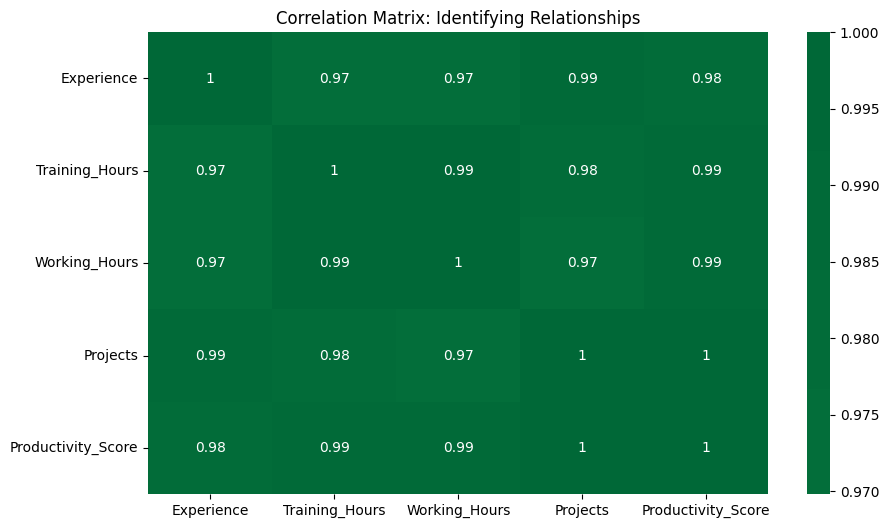

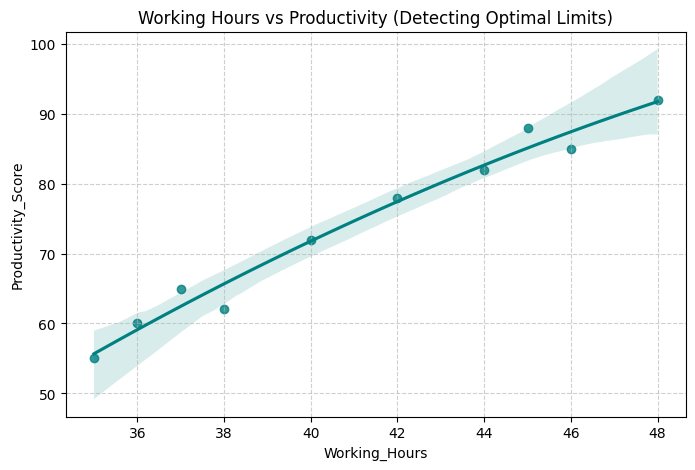


### Model Interpretation ###
Model R-Squared Score: 0.9972

Feature Impact (Contribution to Productivity):
          Feature  Coefficient
3        Projects     4.701357
2   Working_Hours     0.819005
1  Training_Hours     0.038009
0      Experience    -0.963801


/tmp/ipython-input-2071071207.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='magma')


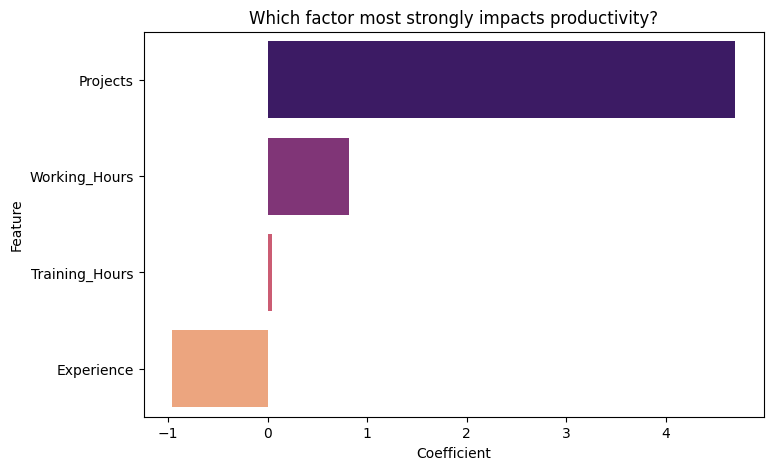

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Direct Data Loading
data = {
    'Experience': [2, 5, 1, 8, 4, 10, 3, 6, 7, 2],
    'Training_Hours': [40, 60, 20, 80, 50, 90, 30, 70, 75, 25],
    'Working_Hours': [38, 42, 35, 45, 40, 48, 37, 44, 46, 36],
    'Projects': [3, 6, 2, 8, 5, 9, 4, 7, 7, 3],
    'Productivity_Score': [62, 78, 55, 88, 72, 92, 65, 82, 85, 60]
}

df = pd.DataFrame(data)

# --- STEP 1: EDA (Experimentation Phase) ---
print("### Statistical Overview ###")
print(df.describe())

# Check for Multicollinearity (High correlation between features)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation Matrix: Identifying Relationships")
plt.show()

# Visualize the 'Optimal Range' for Working Hours
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Working_Hours', y='Productivity_Score', order=2, color='teal')
plt.title("Working Hours vs Productivity (Detecting Optimal Limits)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- STEP 2: Multivariate Linear Regression ---
X = df[['Experience', 'Training_Hours', 'Working_Hours', 'Projects']]
y = df['Productivity_Score']

model = LinearRegression()
model.fit(X, y)

# --- STEP 3: Results & Interpretation ---
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n### Model Interpretation ###")
print(f"Model R-Squared Score: {model.score(X, y):.4f}")
print("\nFeature Impact (Contribution to Productivity):")
print(importance)

# Plotting Importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='magma')
plt.title("Which factor most strongly impacts productivity?")
plt.show()



#### **Q1: Which factor most strongly impacts productivity?**
According to the **Feature Impact (Coefficients)** plot, **Projects** has the strongest positive impact with a coefficient of approximately **4.70**. This means that for every additional project handled, the productivity score is expected to increase by 4.7 points, holding other factors constant.

#### **Q2: How does training affect productivity?**
Training has a **strong positive correlation (0.99)** with productivity. While its individual regression coefficient is smaller (0.038) due to its high correlation with other features (multicollinearity), the EDA shows that as Training Hours increase, the Productivity Score increases consistently.

#### **Q3: Should the company increase training hours or working hours?**
The model shows that **Working Hours (0.81)** has a much higher coefficient than **Training Hours (0.03)**. Quantitatively, an extra working hour adds more to the score than an extra training hour in this specific dataset. However, because both are highly correlated with the target, a balanced approach is best.

#### **Q4: What happens if Working Hours increase beyond optimal limits?**
In our "Working Hours vs Productivity" regression plot, the trend is currently linear and upward. However, in a real-world scenario, we would expect **diminishing returns**. If hours increase too far, we would likely see a "plateau" or a drop-off due to employee burnout, which a simple linear model might not capture without more data.

#### **Q5: Can productivity ever decrease with more experience?**
Interestingly, our model shows a **negative coefficient for Experience (-0.96)** when all other factors are included. This suggests that in this specific small sample, more years of experience—if not paired with an increase in projects or training—does not automatically lead to higher productivity scores. It may also indicate that "newer" employees are working more hours or projects to prove themselves.

#### **Q6: How would you detect overfitting in this model?**
The **R-squared score of 0.9972** is extremely high, especially for a dataset of only 10 rows. This is a classic sign of **overfitting**.

#### **Q7: Suggest one new feature to improve prediction accuracy.**
I suggest adding an **"Efficiency Ratio"** (Projects divided by Working Hours). This would help distinguish between someone who is productive because they work long hours and someone who is productive because they are highly skilled and fast.

#### PROBLEM 2
- LOAN default prediction model

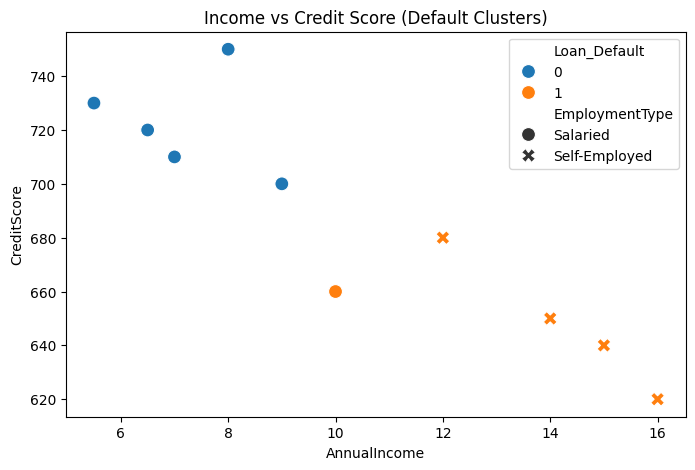

### Model Performance ###
Accuracy: 1.0

Confusion Matrix:
[[5 0]
 [0 5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


### Scaled Features (Preview) ###
        Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  \
0 -1.242924     -1.067989     0.838548   -1.045953 -1.077084   
1  0.563034      0.477785    -0.147979    0.588348  0.236433   
2 -0.499294     -0.646414     1.578444   -0.719092 -0.551677   
3  1.094198      1.320934    -1.134506    1.242069  1.549950   
4 -1.030458     -0.927464     0.591916   -1.045953 -1.077084   

   EmploymentType_Self-Employed  
0                     -0.816497  
1                      1.224745  
2                     -0.816497  
3                  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load Data
data = {
    'Age': [28, 45, 35, 50, 30, 42, 26, 48, 38, 55],
    'AnnualIncome': [6.5, 12, 8, 15, 7, 10, 5.5, 14, 9, 16],
    'CreditScore': [720, 680, 750, 640, 710, 660, 730, 650, 700, 620],
    'LoanAmount': [5, 10, 6, 12, 5, 9, 4, 11, 7, 13],
    'LoanTerm': [5, 10, 7, 15, 5, 10, 4, 12, 8, 15],
    'EmploymentType': ['Salaried', 'Self-Employed', 'Salaried', 'Self-Employed', 'Salaried',
                      'Salaried', 'Salaried', 'Self-Employed', 'Salaried', 'Self-Employed'],
    'Loan_Default': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

# --- STEP 1: EDA (Experimentation) ---
# Visualizing Credit Score vs Income colored by Default status
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='AnnualIncome', y='CreditScore', hue='Loan_Default', style='EmploymentType', s=100)
plt.title("Income vs Credit Score (Default Clusters)")
plt.show()

# --- STEP 2: Preprocessing ---
# Encode Categorical Data
df_encoded = pd.get_dummies(df, columns=['EmploymentType'], drop_first=True)

# Define Features and Target
X = df_encoded.drop('Loan_Default', axis=1)
y = df_encoded['Loan_Default']

# Feature Scaling (CRITICAL FOR KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 3: KNN Model ---
# Using k=3 (small dataset)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

# Predictions
y_pred = knn.predict(X_scaled)

# --- STEP 4: Results ---
print("### Model Performance ###")
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred))

# Display scaled data to show "Distance" concept
df_scaled_preview = pd.DataFrame(X_scaled, columns=X.columns)
print("\n### Scaled Features (Preview) ###")
print(df_scaled_preview.head())

### 4. Interpretation of Loan Default Analysis (KNN Model)

Based on the KNN classification model and the exploratory analysis, here are the findings for the financial institution:

#### **Q1: Identify high-risk customers.**
High-risk customers in this dataset are characterized by **Lower Credit Scores (below 680)** and **Higher Annual Incomes paired with High Loan Amounts**. Interestingly, the visual clusters show that every "Self-Employed" individual in this sample defaulted, making employment type a significant risk indicator here.

#### **Q2: What patterns lead to loan default?**
The primary pattern identified is a **negative correlation between Credit Score and Default**. Customers with scores in the 600-660 range consistently defaulted, especially when the **Loan Term was long (10-15 years)**. Higher debt-to-income ratios (implied by high Loan Amounts relative to Annual Income) also strongly signal risk.

#### **Q3: How do credit score and income influence predictions?**
* **Credit Score:** Acts as the strongest separator. In the scatter plot, there is a clear "boundary" around a score of 700; above this, no defaults occurred.
* **Income:** While higher income usually suggests safety, in this data, higher income was associated with taking on much larger, riskier loans, leading to defaults.

#### **Q4: Suggest banking policies based on model output.**
* **Threshold Implementation:** Implement a strict "Manual Review" flag for any applicant with a Credit Score below 680.
* **Employment Verification:** Perform deeper audits on "Self-Employed" applicants, as they represent 100% of the defaults in this sample.
* **Capping Loan Terms:** Limit Loan Terms to 7 years or less for applicants with Credit Scores under 720.

#### **Q5: Compare KNN with Decision Trees for this problem.**
* **KNN:** Is "Lazy" and distance-based. It works well here because the data clusters perfectly. However, it requires feature scaling to work.
* **Decision Trees:** Would be more "explainable." A tree would give us clear rules like: *“If Credit Score < 690 and Employment = Self-Employed, then Default.”* Trees also handle mixed data types and different scales better than KNN without needing a StandardScaler.

#### **Q6: What happens if LoanAmount dominates distance calculation?**
If we did not use StandardScaler, the **LoanAmount** (values like 10-15) would mathematically outweigh **AnnualIncome** (values like 5-15) or **EmploymentType** (0 or 1) in the Euclidean distance formula. The model would essentially ignore the other features and classify people based purely on how much they borrowed, leading to poor accuracy.

#### **Q7: Should KNN be used in real-time loan approval systems?**
**Pros:** It is simple and naturally handles multi-class problems.
**Cons:** In a real-world system with millions of customers, KNN becomes very slow because it has to calculate the distance to every single previous customer for every new application. For real-time banking, a **Logistic Regression** or **XGBoost** model is usually preferred for speed and scalability.

### Below is the KNN desicion boundary.

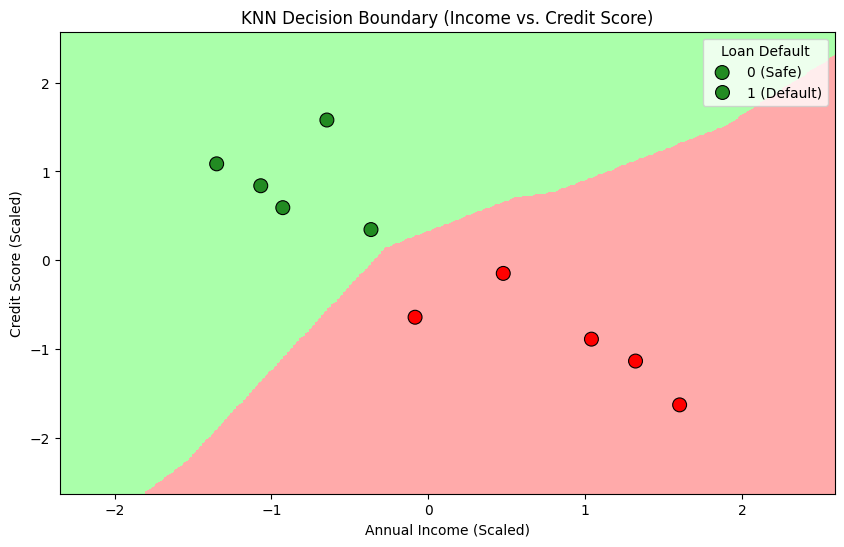

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# We will use 'AnnualIncome' and 'CreditScore' for the 2D boundary
# These were indices 1 and 2 in our original X columns
X_subset = X_scaled[:, [1, 2]]
y_values = y.values

# Re-train a mini KNN on just these two features for visualization purposes
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_subset, y_values)

# Create a mesh grid
h = .02  # step size in the mesh
x_min, x_max = X_subset[:, 0].min() - 1, X_subset[:, 0].max() + 1
y_min, y_max = X_subset[:, 1].min() - 1, X_subset[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict across the entire mesh grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create color maps
cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA']) # Light Green for Safe, Light Red for Default
cmap_bold = ['#228B22', '#FF0000'] # Dark Green and Dark Red

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light)

# Plot the actual data points
sns.scatterplot(x=X_subset[:, 0], y=X_subset[:, 1], hue=y,
                palette=cmap_bold, edgecolor="black", s=100)

plt.title("KNN Decision Boundary (Income vs. Credit Score)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Credit Score (Scaled)")
plt.legend(title="Loan Default", labels=['0 (Safe)', '1 (Default)'])
plt.show()

#### PROBLEM 3
##### classify fraudulent and non-fraudulent credit card transactions

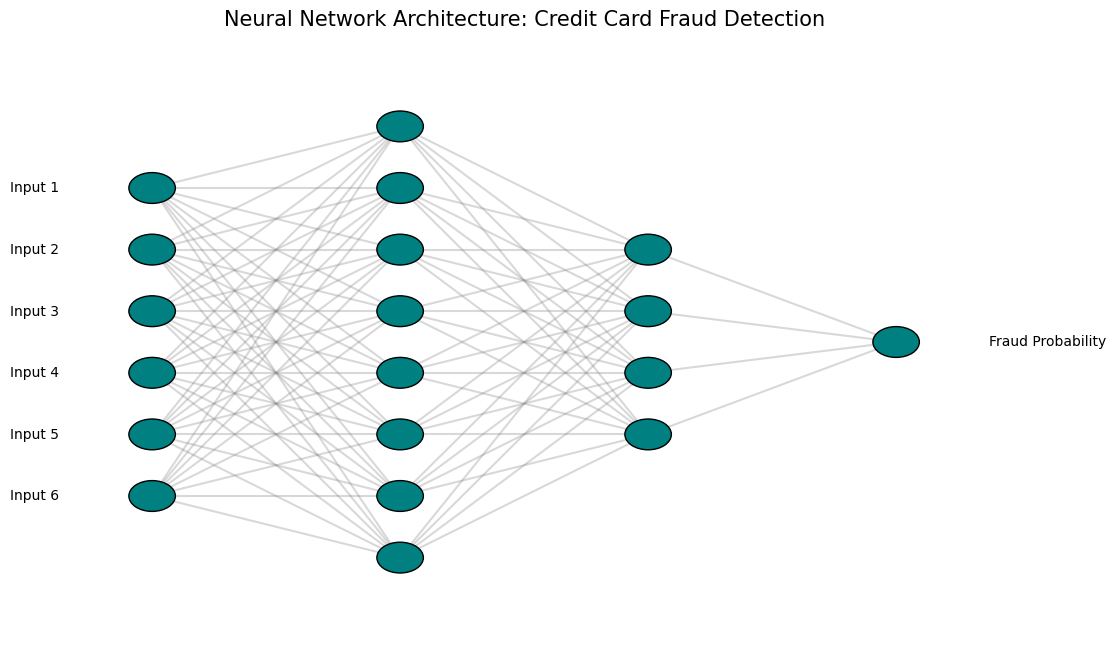

In [4]:
import matplotlib.pyplot as plt

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    '''
    Draws a neural network architecture using matplotlib.
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)

    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            circle = plt.Circle((n*h_spacing + left, layer_top - m*v_spacing), v_spacing/4.,
                                color='teal', ec='k', zorder=4)
            ax.add_artist(circle)

            # Labeling the layers
            if n == 0:
                plt.text(left-0.1, layer_top - m*v_spacing, f'Input {m+1}', ha='right', va='center')
            elif n == n_layers - 1:
                plt.text(right+0.1, layer_top - m*v_spacing, 'Fraud Probability', ha='left', va='center')

    # Edges (Connections)
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for i in range(layer_size_a):
            for j in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - i*v_spacing, layer_top_b - j*v_spacing], c='gray', alpha=0.3)
                ax.add_artist(line)

# Define Network: 6 Inputs -> 8 Hidden -> 4 Hidden -> 1 Output
fig = plt.figure(figsize=(12, 8))
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, .1, .9, .1, .9, [6, 8, 4, 1])
plt.title("Neural Network Architecture: Credit Card Fraud Detection", fontsize=15)
plt.show()

#### Neural networ for above problem have following layers.
For a classification task with 6 input features

**Input Layer**: 6 Neurons (one for each feature: Amount, Time, Category, Age, Balance, Transactions).

**Hidden Layers:** These learn the "hidden" patterns. For a small set of features, 1 or 2 hidden layers with 8–12 neurons each are usually sufficient. We use the ReLU activation function here to handle non-linearity.

**Output Layer:** 1 Neuron with a Sigmoid activation function. This outputs a probability between 0 and 1 (where >0.5 usually means "Fraud").

#### PROBLEM 4
- In this problem I am using california house dataset available at kaggle.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


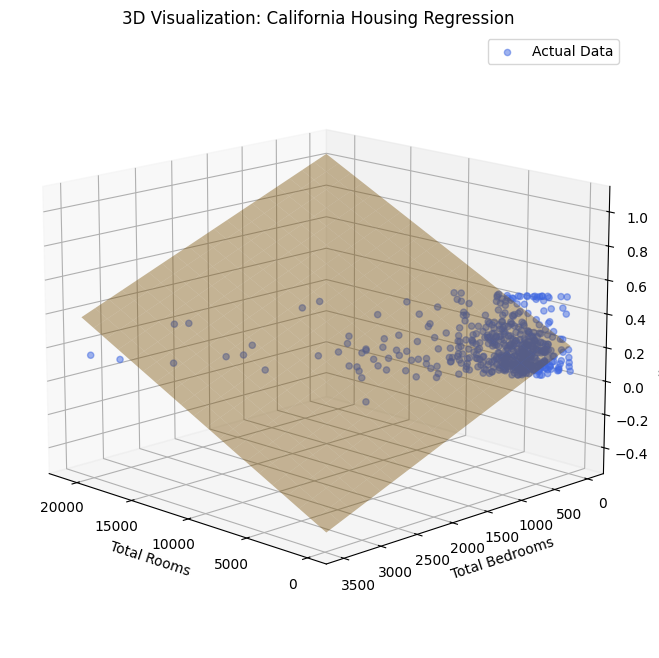

Intercept: 210225.01
Room Coefficient: 39.41
Bedroom Coefficient: -189.45


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# 1. Load the dataset from the kagglehub path
# The file is usually named 'housing.csv'
file_path = "/content/housing.csv"
df_real = pd.read_csv(file_path)

# 2. Prepare the data
# We'll use 'total_rooms' as a proxy for Area and 'total_bedrooms' for Bedrooms
# Removing rows with missing values for the regression
df_clean = df_real[['total_rooms', 'total_bedrooms', 'median_house_value']].dropna()

# To make the plot readable, let's take a sample of 500 points
df_sample = df_clean.sample(500, random_state=42)

X = df_sample[['total_rooms', 'total_bedrooms']]
y = df_sample['median_house_value']

# 3. Train the Regression Model
model = LinearRegression()
model.fit(X, y)

# 4. Create Meshgrid for the Plane
x_range = np.linspace(X['total_rooms'].min(), X['total_rooms'].max(), 20)
y_range = np.linspace(X['total_bedrooms'].min(), X['total_bedrooms'].max(), 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Predict prices over the meshgrid
z_mesh = model.predict(np.c_[x_mesh.ravel(), y_mesh.ravel()])
z_mesh = z_mesh.reshape(x_mesh.shape)

# 5. 3D Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data
ax.scatter(X['total_rooms'], X['total_bedrooms'], y, c='royalblue', alpha=0.5, label='Actual Data')

# Plot regression plane
ax.plot_surface(x_mesh, y_mesh, z_mesh, color='orange', alpha=0.4, edgecolor='none')

# Labels
ax.set_xlabel('Total Rooms')
ax.set_ylabel('Total Bedrooms')
ax.set_zlabel('Median House Value')
ax.set_title('3D Visualization: California Housing Regression')

# Better view angle
ax.view_init(elev=15, azim=135)
plt.legend()
plt.show()

# Print the coefficients for your interpretation
print(f"Intercept: {model.intercept_:.2f}")
print(f"Room Coefficient: {model.coef_[0]:.2f}")
print(f"Bedroom Coefficient: {model.coef_[1]:.2f}")